### Annotating DC2 sub-clusters based off DEGS and published signatures

In [1]:
#load packages I need
import os
import tools
import scanpy as sc
import pandas as pd
import dandelion as ddl
from tqdm import tqdm
import matplotlib.pyplot as plt
import scanpy.external as sce
from matplotlib.pyplot import rc_context
import seaborn as sns

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [2]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects'

In [3]:
# read in data
data_DC = sc.read_h5ad('20250617_AllDC_bbknn.h5ad')
data = sc.read_h5ad('NRclean_clustered2.h5ad')
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

: 

: 

: 

In [4]:
# Set colours for NR_annotations_simple plot:
data_DC.uns["NR_annotations_simple_colors"] = ['#e377c2', '#aa40fc', '#8c564b']  

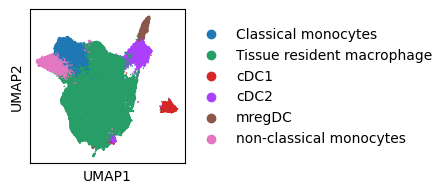

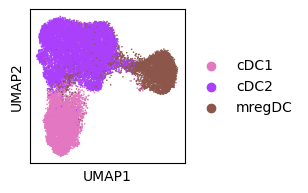

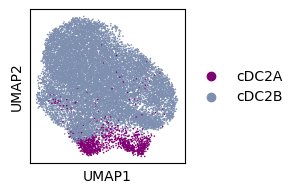

In [5]:
#output umap
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data, color="MyeloidAPC_Subsets", size=5, title="")
    sc.pl.umap(data_DC, color="NR_annotations_simple", size=5, title="")
    sc.pl.umap(data_DC2, color="cDC2_A-B", size=5, title="")

In [3]:
data_DC2 = sc.read_h5ad('20250629_DC2_bbknn_clustered2.h5ad')

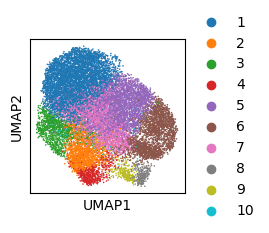

In [4]:
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="cDC2_Atlas_Subclusters", size=5, title="")

### Remove cluster 2 and 10 from DC2 object

In [5]:
data_DC2 = data_DC2[~data_DC2.obs["cDC2_Atlas_Subclusters"].isin(["2","10"])]

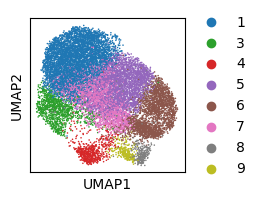

In [6]:
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="cDC2_Atlas_Subclusters", size=5, title="")

### Add DC2 subcluster annotations

In [7]:
data_DC2

View of AnnData object with n_obs × n_vars = 15042 × 2001
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'Guimaraes_DC2_FCER1A', 'Guimaraes_DC2_AREG', 'Guimaraes_Cheng_DC2_CD207/CD1A', 'Guimaraes_DC3_CD14', 'Guimaraes_DC4_FCGR3A', 'Guimaraes_DC_CXCL2', 'Cheng_DC2_CXCR4', 'Cheng_DC2_IL1B', 'Cheng_DC2_FCN1', 'Cheng_DC2_ISG15', 'Cheng_DC2_

In [8]:
# Assign DC2 annotations:
data_DC2.obs["cDC2_sub_annotated"] = data_DC2.obs["cDC2_Atlas_Subclusters"].map(
    {
        "1": "DC3-like cDC2",
        "3": "SIK3 cDC2",
        "4": "CD207-S100 cDC2",
        "5": "classical cDC2",
        "6": "ISG cDC2",
        "7": "classical cDC2",
        "8": "CD207-IL18 cDC2",
        "9": "CD207-LTB cDC2",
    }
)

/scratch/temp/28490836/ipykernel_3200070/1772058588.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [ ]:
# Assign DC2 annotations:
data_DC2.obs["cDC2_sub_annotated"] = data_DC2.obs["cDC2_Atlas_Subclusters"].map(
    {
        "1": "DC3-like cDC2",
        "3": "IL-1B cDC2",
        "4": "CD207 cDC2",
        "5": "classical cDC2",
        "6": "ascites classical cDC2",
        "7": "classical cDC2",
        "8": "CD207/LTB cDC2 ?",
        "9": "LTB cDC2",
    }
)

In [56]:
#only run for UMAPs
sc.set_figure_params(dpi=80, dpi_save=700, vector_friendly=True, format='svg')

In [9]:
print(data_DC2.uns["cDC2_Atlas_Subclusters_colors"])

['#1f77b4' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2' '#7f7f7f'
 '#bcbd22']


In [ ]:
# Set colours for cDC2_sub_annotated plot:
data_DC2.uns["cDC2_sub_annotated_colors"] = ['#d62728', '#7f7f7f', '#1f77b4', '#2ca02c', '#bcbd22', '#8c564b','#c869c9']

In [11]:
# Set colours for cDC2_sub_annotated plot: - new
data_DC2.uns["cDC2_sub_annotated_colors"] = ['#7f7f7f','#bcbd22','#d62728','#1f77b4','#8c564b','#2ca02c','#c869c9']

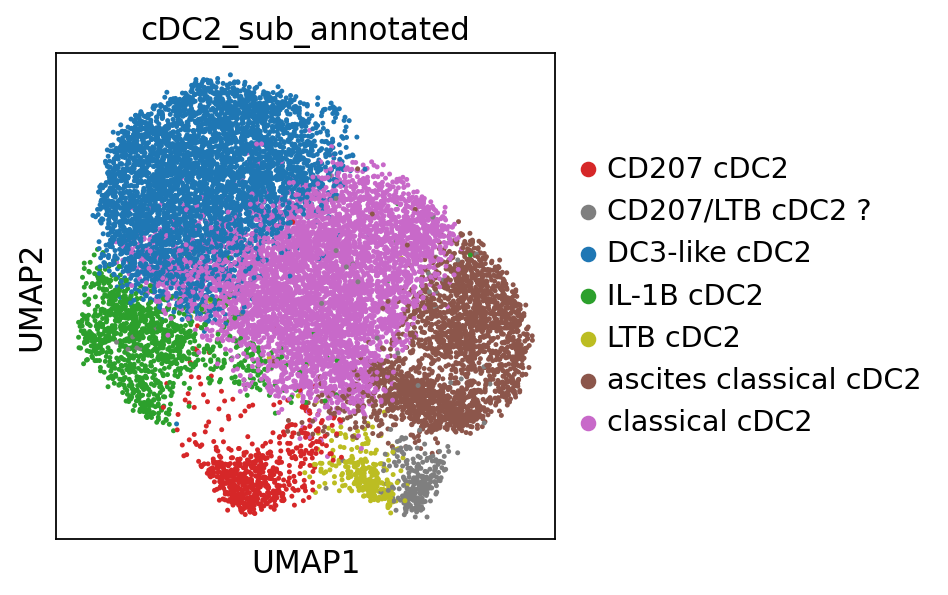

In [58]:
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC2, color="cDC2_sub_annotated", size=20, save="_DC2_annotated_v2.svg")

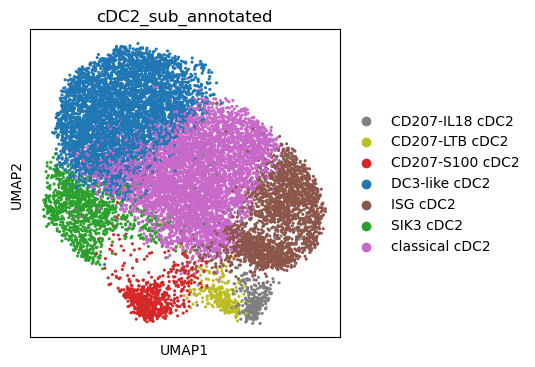

In [12]:
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC2, color="cDC2_sub_annotated", size=20)

In [59]:
#Calculate DEGs between new cDC2 annotations 
sc.tl.rank_genes_groups(data_DC2, groupby="cDC2_sub_annotated", method="wilcoxon", key_added="cDC2_sub_annotated_DEGS")

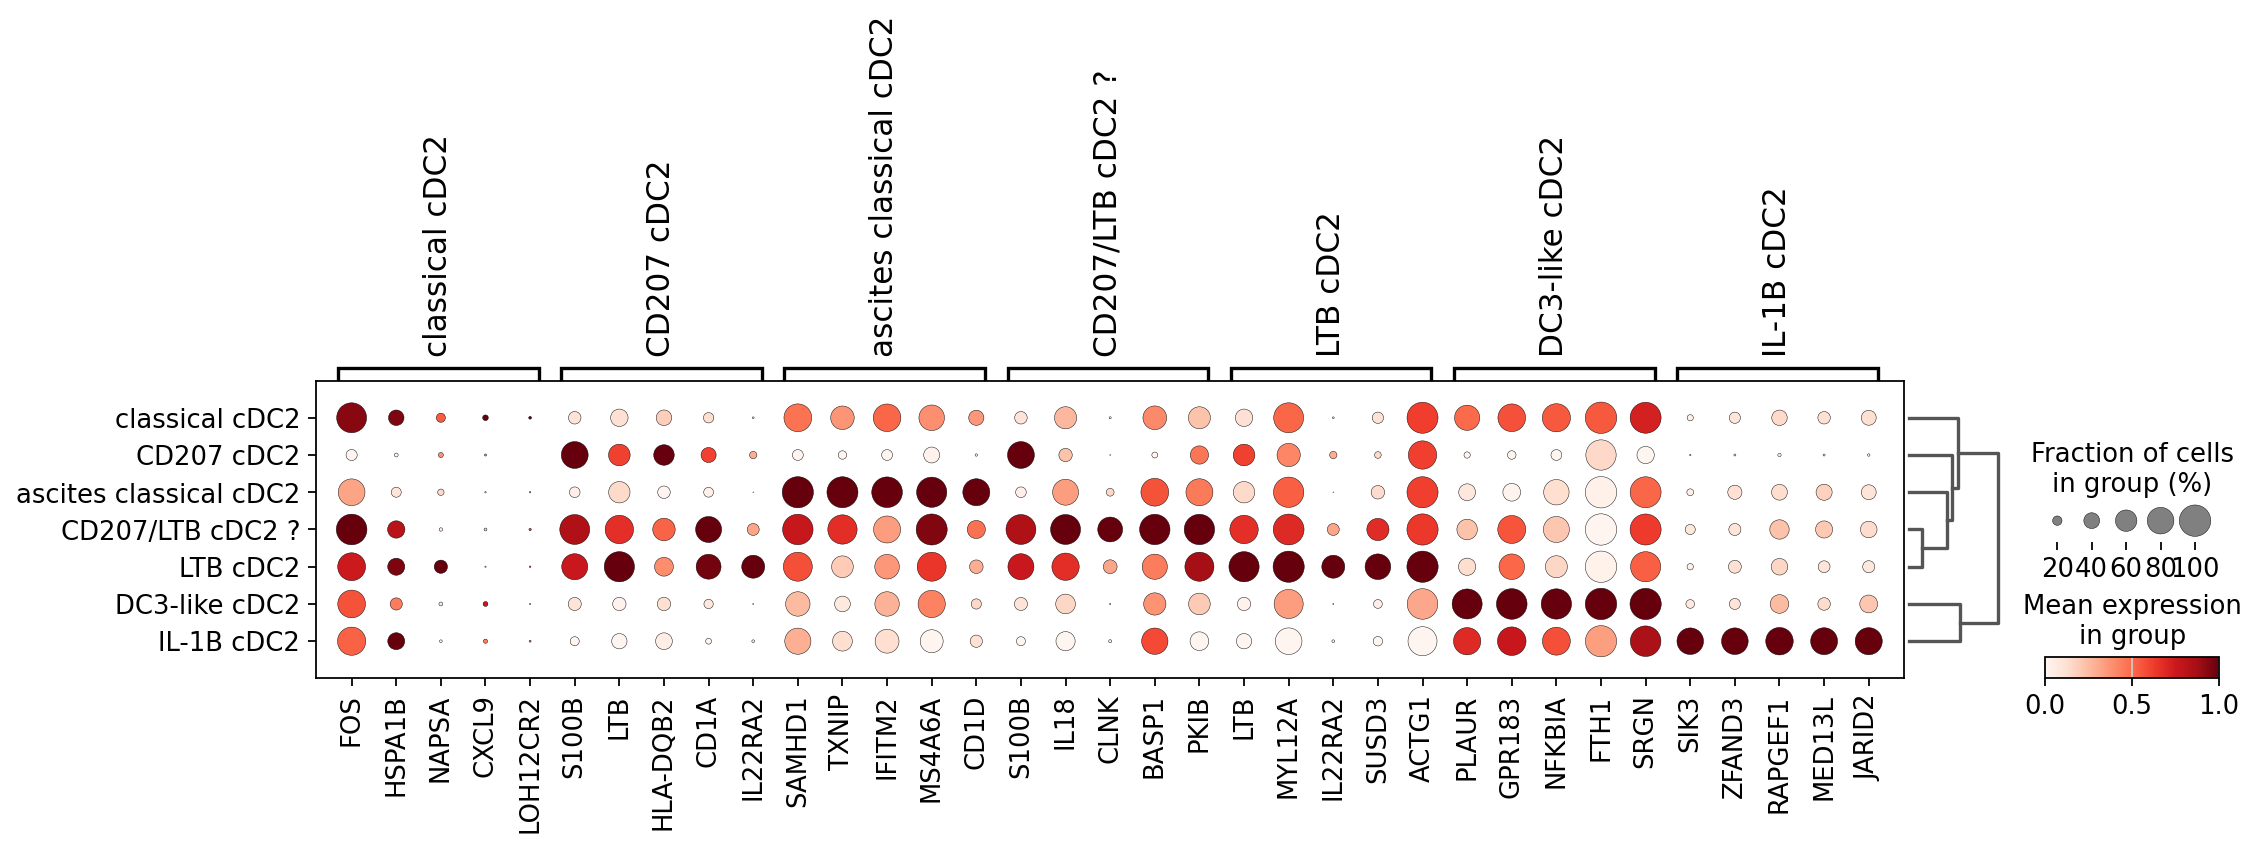

In [ ]:
#visualise the top 10 DEG genes for each cluster
sc.pl.rank_genes_groups_dotplot(
    data_DC2, groupby="cDC2_sub_annotated", standard_scale="var", n_genes=5, min_logfoldchange=1, key="cDC2_sub_annotated_DEGS", save="DC2_sub_annotated_degs.svg"
)

In [69]:
# read out for each cluster
DC2_class = sc.get.rank_genes_groups_df(data_DC2, group="classical cDC2", key="cDC2_sub_annotated_DEGS")
DC2_CD207 = sc.get.rank_genes_groups_df(data_DC2, group="CD207 cDC2", key="cDC2_sub_annotated_DEGS")
DC2_asc = sc.get.rank_genes_groups_df(data_DC2, group="ascites classical cDC2", key="cDC2_sub_annotated_DEGS")
DC2_OC_CD207 = sc.get.rank_genes_groups_df(data_DC2, group="CD207/LTB cDC2 ?", key="cDC2_sub_annotated_DEGS")
DC2_LTB = sc.get.rank_genes_groups_df(data_DC2, group="LTB cDC2", key="cDC2_sub_annotated_DEGS")
DC2_DC3 = sc.get.rank_genes_groups_df(data_DC2, group="DC3-like cDC2", key="cDC2_sub_annotated_DEGS")
DC2_IL1b = sc.get.rank_genes_groups_df(data_DC2, group="IL-1B cDC2", key="cDC2_sub_annotated_DEGS")

In [70]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects/DC2_annotated_DEGS_NEW')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects/DC2_annotated_DEGS_NEW'

In [71]:
DC2_CD207.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,S100B,30.063126,4.922900,1.470914e-198,4.139152e-195
1,RPS19,20.661324,0.515470,7.721861e-95,5.543193e-93
2,TMSB10,20.489567,0.661871,2.667591e-93,1.848917e-91
3,GAPDH,16.863256,0.678884,8.383997e-64,2.259825e-62
4,PFN1,16.502356,0.669523,3.528558e-61,8.740637e-60


In [72]:
# check what the smallest p value python can output is (set any equal to zero to this)
import numpy as np
np.finfo(np.float64).tiny

#would set floor to this, however excel (which will use for subsequent analysis has a floor of 1e-307, so instead set minimum to this)

np.float64(2.2250738585072014e-308)

In [73]:
# change any p values that are 0.0 to 2.2250738585072014e-308
min_float = 1e-307
DC2_class['pvals'] = DC2_class['pvals'].replace(0.0, min_float)
DC2_class['pvals_adj'] = DC2_class['pvals_adj'].replace(0.0, min_float)
DC2_CD207['pvals'] = DC2_CD207['pvals'].replace(0.0, min_float)
DC2_CD207['pvals_adj'] = DC2_CD207['pvals_adj'].replace(0.0, min_float)
DC2_asc['pvals'] = DC2_asc['pvals'].replace(0.0, min_float)
DC2_asc['pvals_adj'] = DC2_asc['pvals_adj'].replace(0.0, min_float)
DC2_OC_CD207['pvals'] = DC2_OC_CD207['pvals'].replace(0.0, min_float)
DC2_OC_CD207['pvals_adj'] = DC2_OC_CD207['pvals_adj'].replace(0.0, min_float)
DC2_LTB['pvals'] = DC2_LTB['pvals'].replace(0.0, min_float)
DC2_LTB['pvals_adj'] = DC2_LTB['pvals_adj'].replace(0.0, min_float)
DC2_DC3['pvals'] = DC2_DC3['pvals'].replace(0.0, min_float)
DC2_DC3['pvals_adj'] = DC2_DC3['pvals_adj'].replace(0.0, min_float)
DC2_IL1b['pvals'] = DC2_IL1b['pvals'].replace(0.0, min_float)
DC2_IL1b['pvals_adj'] = DC2_IL1b['pvals_adj'].replace(0.0, min_float)

In [74]:
DC2_class.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,FOS,45.621311,1.633808,1.000000e-307,1.000000e-307
1,ACTB,28.842144,0.622485,6.357386e-183,4.472421e-179
2,DUSP1,27.005583,0.912998,1.270852e-160,5.960295e-157
3,ZFP36,26.209023,0.812090,2.097116e-151,7.376604e-148
4,JUNB,24.229288,0.712509,1.093338e-129,3.076653e-126


In [75]:
# save degs
DC2_class.to_csv("DEGs_newDC2_classicalDC2_v2.csv", index=False)
DC2_CD207.to_csv("DEGs_newDC2_CD207_v2.csv", index=False)
DC2_asc.to_csv("DEGs_newDC2_AscDC2_v2.csv", index=False)
DC2_OC_CD207.to_csv("DEGs_newDC2_OC_CD207_v2.csv", index=False)
DC2_LTB.to_csv("DEGs_newDC2_LTB_v2.csv", index=False)
DC2_DC3.to_csv("DEGs_newDC2_DC3_v2.csv", index=False)
DC2_IL1b.to_csv("DEGs_newDC2_IL1B_v2.csv", index=False)


In [13]:
#Calculate DEGs between new cDC2 annotations 
sc.tl.rank_genes_groups(data_DC2, groupby="cDC2_sub_annotated", method="wilcoxon", key_added="cDC2_sub_annotated_DEGS_v2")

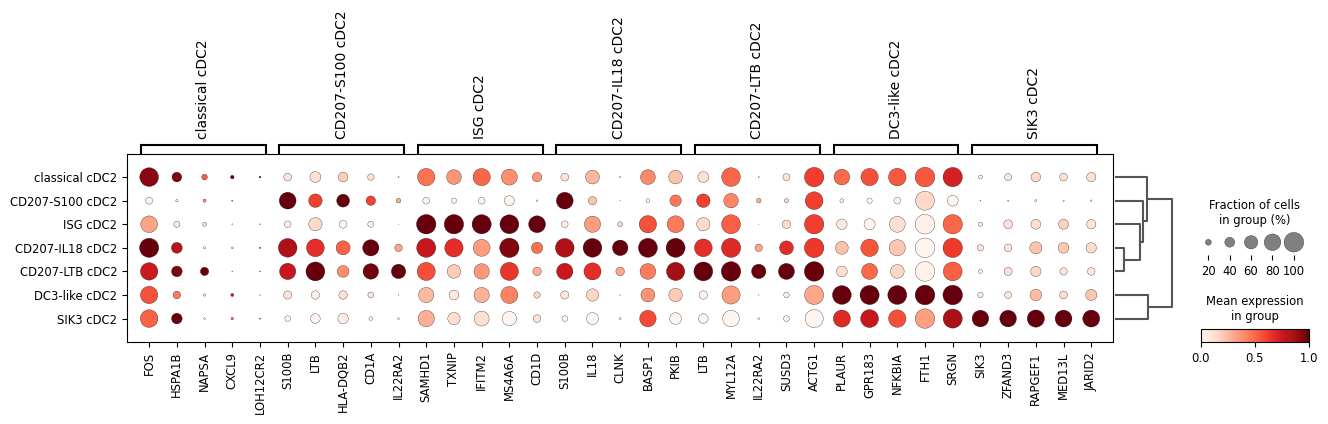

In [14]:
#visualise the top 10 DEG genes for each cluster
sc.pl.rank_genes_groups_dotplot(
    data_DC2, groupby="cDC2_sub_annotated", standard_scale="var", n_genes=5, min_logfoldchange=1, key="cDC2_sub_annotated_DEGS_v2"
)

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


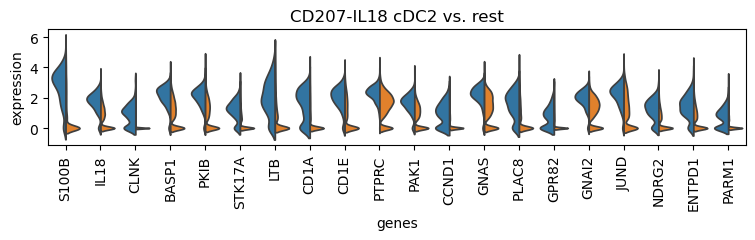

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


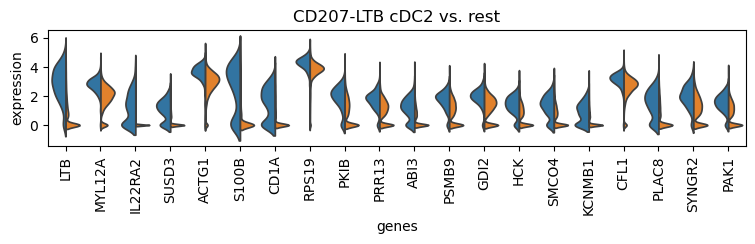

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


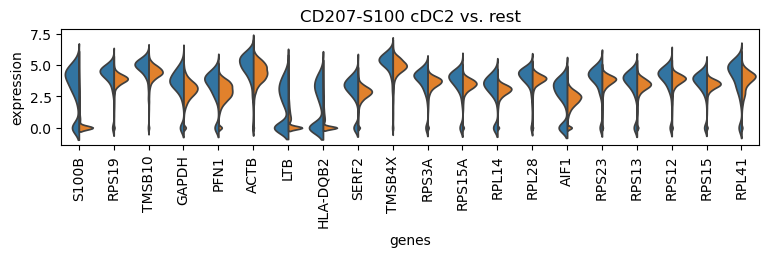

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


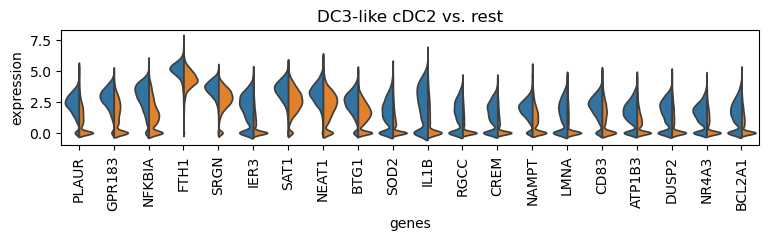

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


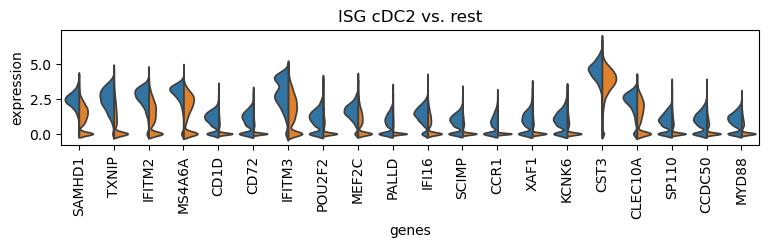

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


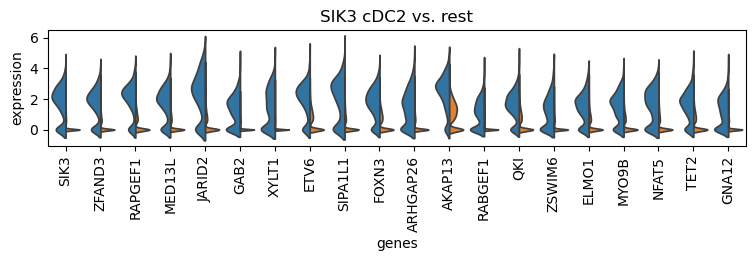

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


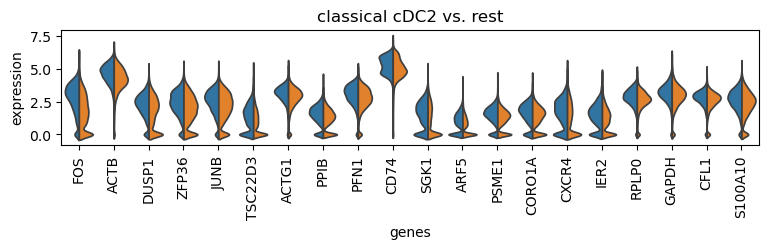

In [27]:
with rc_context({"figure.figsize": (9, 1.5)}):
    sc.pl.rank_genes_groups_violin(data_DC2, key="cDC2_sub_annotated_DEGS_v2", n_genes=20, strip=False)

# Breakdown: 

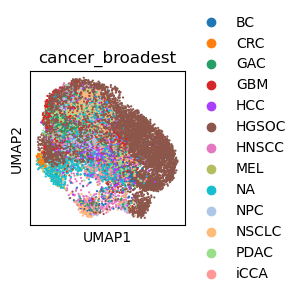

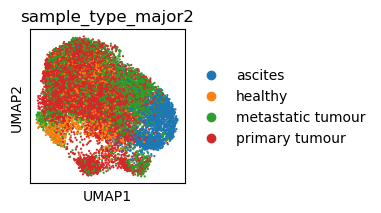

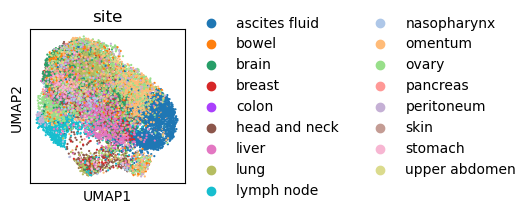

In [11]:
with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="cancer_broadest", size=10)

with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="sample_type_major2", size=10)

with plt.rc_context({"figure.figsize": (2, 2)}):
    sc.pl.umap(data_DC2, color="site", size=10)

In [12]:
# breakdown by cancer type: 

#define function
def cluster_small_multiples(
    data_int, clust_key, size=40, frameon=False, legend_loc=None, title_fontsize=12, **kwargs
):
    tmp = data_int.copy()

    for i, clust in enumerate(data_int.obs[clust_key].cat.categories):
        tmp.obs[clust] = data_int.obs[clust_key].isin([clust]).astype("category")
        tmp.uns[clust + "_colors"] = ["#d3d3d3", "#10047B"]

    fig = sc.pl.umap(
        tmp,
        groups=tmp.obs[clust].cat.categories[1:].values,
        color=data_int.obs[clust_key].cat.categories.tolist(),
        size=size,
        frameon=frameon,
        legend_loc=legend_loc,
        return_fig=True,
        **kwargs
    )

    for ax in fig.axes:
        ax.title.set_fontsize(title_fontsize)

    return fig


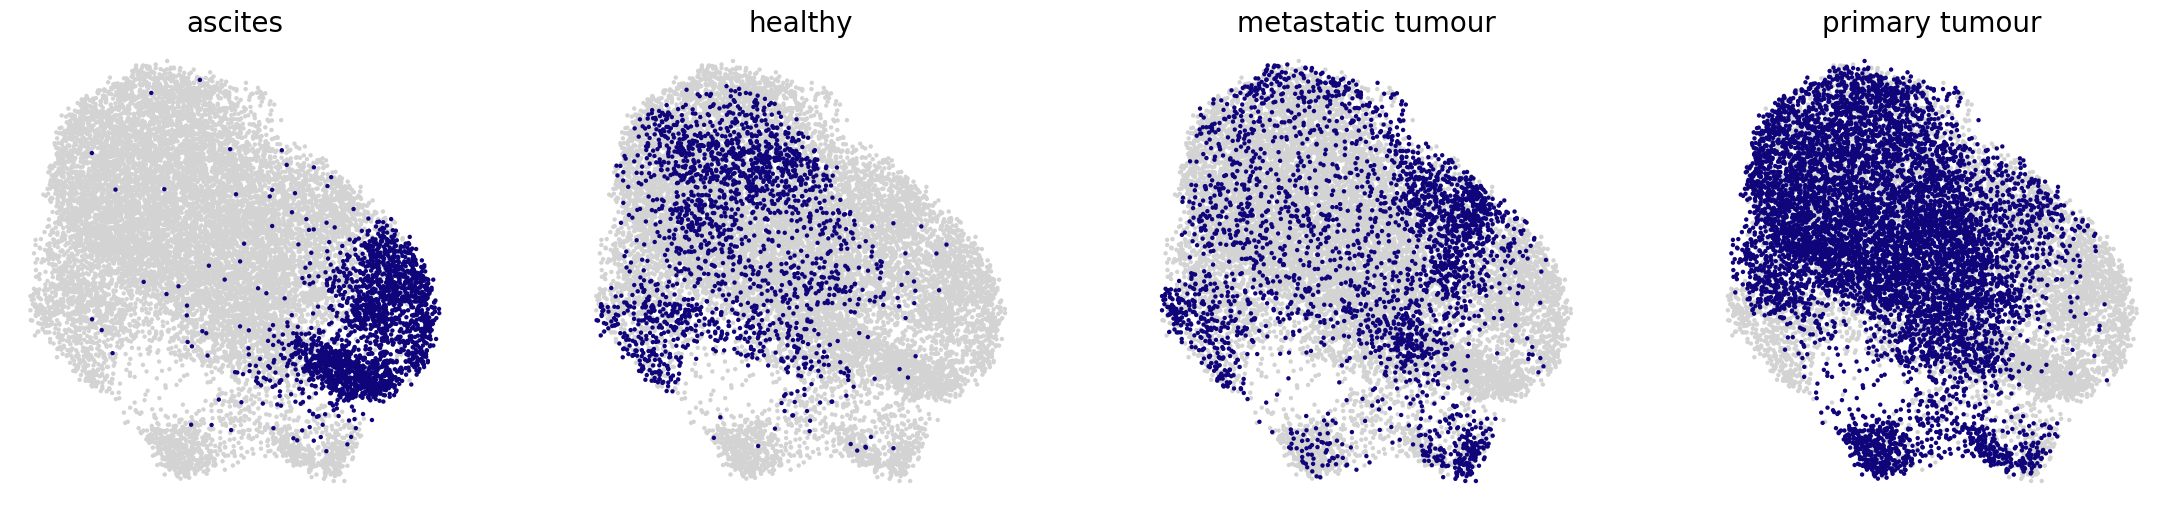

In [13]:
with plt.rc_context({"figure.figsize": (6, 6)}):
    fig = cluster_small_multiples(data_DC2, "sample_type_major2", title_fontsize=20)
    plt.show()

# Breakdown bar graphs:

In [14]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects/DC2_Re-Clustering_Exports')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects/DC2_Re-Clustering_Exports'

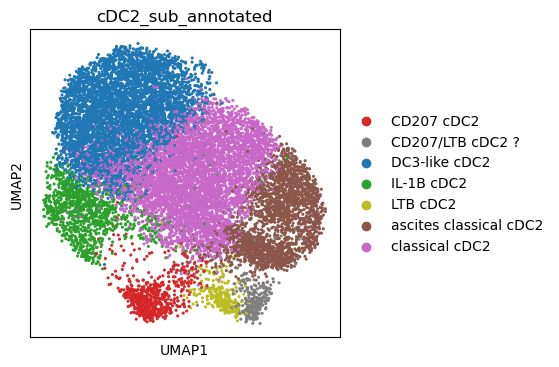

In [15]:
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC2, color="cDC2_sub_annotated", size=20)

In [16]:
# set colours for bar graph
colours10 = data_DC2.uns["cDC2_sub_annotated_colors"]
clusters = data_DC2.obs["cDC2_sub_annotated"].cat.categories
colour_dict = dict(zip(clusters, colours10))

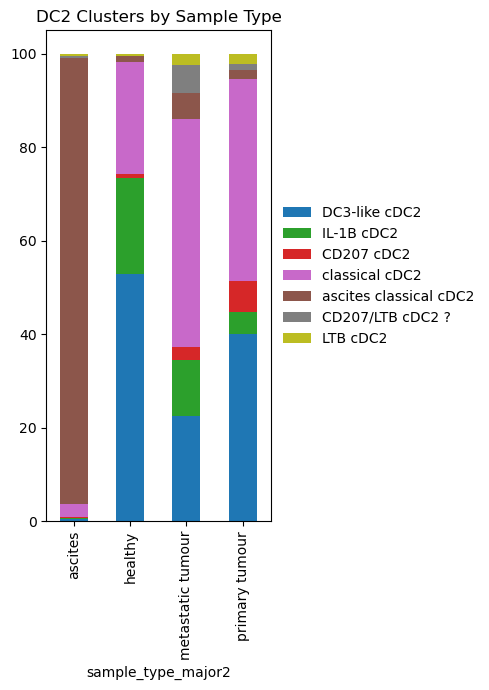

In [ ]:
#plot stacked graph by sample type
ct = pd.crosstab(data_DC2.obs["sample_type_major2"], data_DC2.obs["cDC2_sub_annotated"])
ct_pct = ct.apply(lambda r: r / r.sum() * 100, axis=1)

# set order for stack
ct_pct = ct_pct[["DC3-like cDC2","IL-1B cDC2","CD207 cDC2","classical cDC2","ascites classical cDC2","CD207/LTB cDC2 ?","LTB cDC2"]]

colours = [colour_dict[col] for col in ct_pct.columns]
ct_pct.plot.bar(stacked=True, figsize=(5,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_annotated_v2_sample_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [18]:
data_DC2_primary = data_DC2[data_DC2.obs["sample_type_major2"] == "primary tumour"]
data_DC2_mets = data_DC2[data_DC2.obs["sample_type_major2"] == "metastatic tumour"]
data_DC2_H = data_DC2[data_DC2.obs["sample_type_major2"] == "healthy"]
data_DC2_OC = data_DC2[data_DC2.obs["cancer_with_H"] == "HGSOC"]

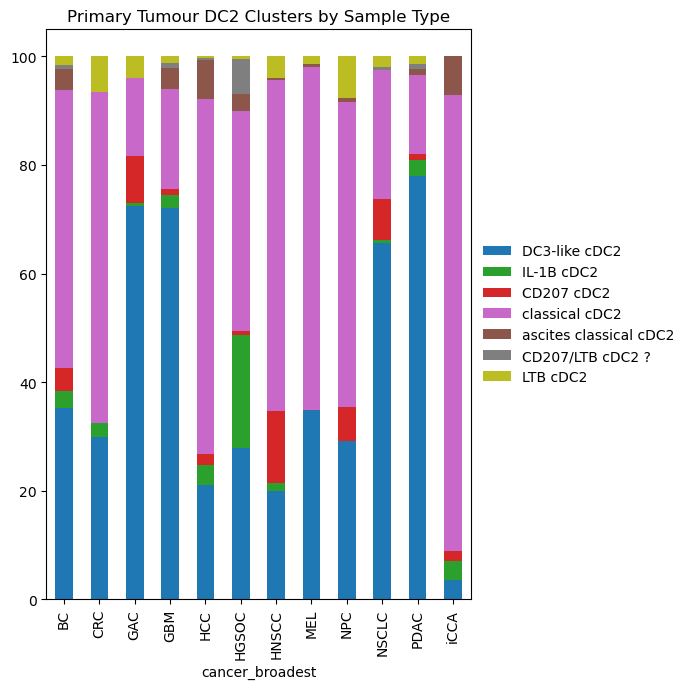

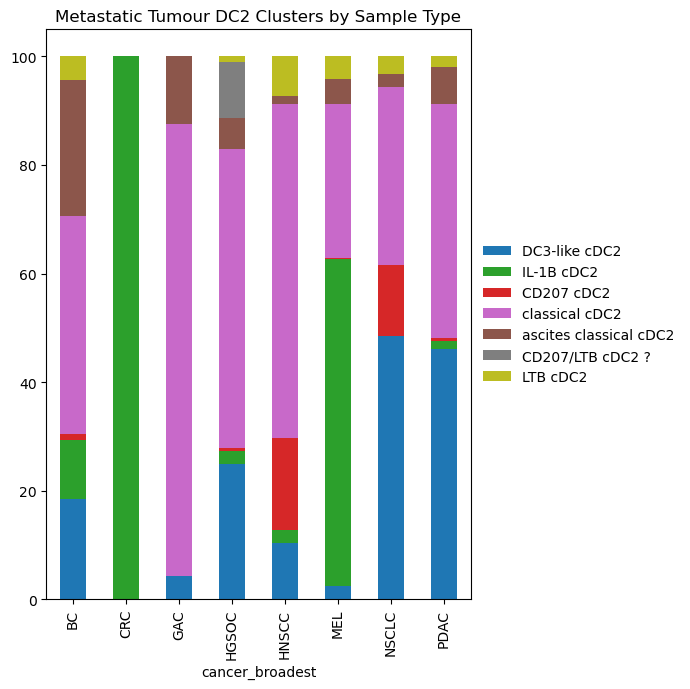

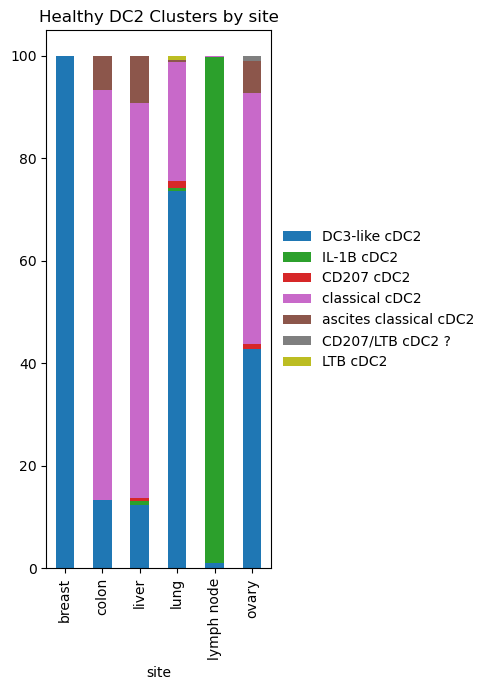

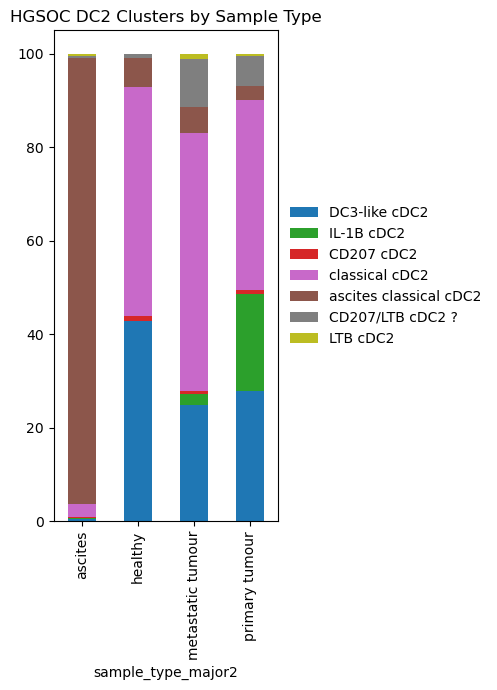

In [20]:

# plot stacked graph by cancer type for primary samples only
ct1 = pd.crosstab(data_DC2_primary.obs["cancer_broadest"], data_DC2_primary.obs["cDC2_sub_annotated"])
ct1_pct = ct1.apply(lambda r: r / r.sum() * 100, axis=1)
ct1_pct = ct1_pct[["DC3-like cDC2","IL-1B cDC2","CD207 cDC2","classical cDC2","ascites classical cDC2","CD207/LTB cDC2 ?","LTB cDC2"]]
colours = [colour_dict[col] for col in ct1_pct.columns]
ct1_pct.plot.bar(stacked=True, figsize=(7,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Primary Tumour DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_annotated_v2_primary_cancer_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

# plot stacked graph by cancer type for metastatic samples only
ct2 = pd.crosstab(data_DC2_mets.obs["cancer_broadest"], data_DC2_mets.obs["cDC2_sub_annotated"])
ct2_pct = ct2.apply(lambda r: r / r.sum() * 100, axis=1)
ct2_pct = ct2_pct[["DC3-like cDC2","IL-1B cDC2","CD207 cDC2","classical cDC2","ascites classical cDC2","CD207/LTB cDC2 ?","LTB cDC2"]]
colours = [colour_dict[col] for col in ct2_pct.columns]
ct2_pct.plot.bar(stacked=True, figsize=(7,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Metastatic Tumour DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_annotated_v2_mets_cancer_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

# plot stacked graph by site for healthy samples only
ct3 = pd.crosstab(data_DC2_H.obs["site"], data_DC2_H.obs["cDC2_sub_annotated"])
ct3_pct = ct3.apply(lambda r: r / r.sum() * 100, axis=1)
ct3_pct = ct3_pct[["DC3-like cDC2","IL-1B cDC2","CD207 cDC2","classical cDC2","ascites classical cDC2","CD207/LTB cDC2 ?","LTB cDC2"]]
colours = [colour_dict[col] for col in ct3_pct.columns]
ct3_pct.plot.bar(stacked=True, figsize=(5,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Healthy DC2 Clusters by site")
plt.tight_layout()  
plt.savefig("barplot_DC2_annotated_v2_healthy_site.pdf", format="pdf", bbox_inches="tight")
plt.show()

# plot stacked graph by sample type for HGSOC samples only
ct4 = pd.crosstab(data_DC2_OC.obs["sample_type_major2"], data_DC2_OC.obs["cDC2_sub_annotated"])
ct4_pct = ct4.apply(lambda r: r / r.sum() * 100, axis=1)
ct4_pct = ct4_pct[["DC3-like cDC2","IL-1B cDC2","CD207 cDC2","classical cDC2","ascites classical cDC2","CD207/LTB cDC2 ?","LTB cDC2"]]
colours = [colour_dict[col] for col in ct4_pct.columns]
ct4_pct.plot.bar(stacked=True, figsize=(5,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("HGSOC DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_annotated_v2_HGSOC_sample_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

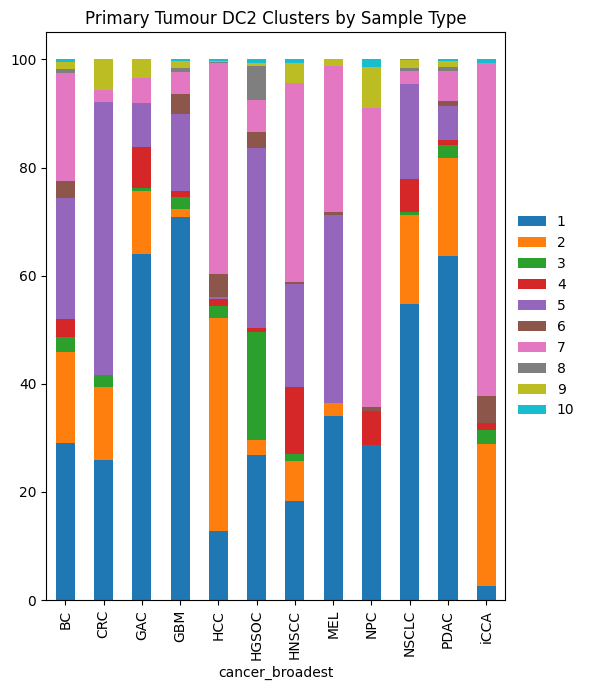

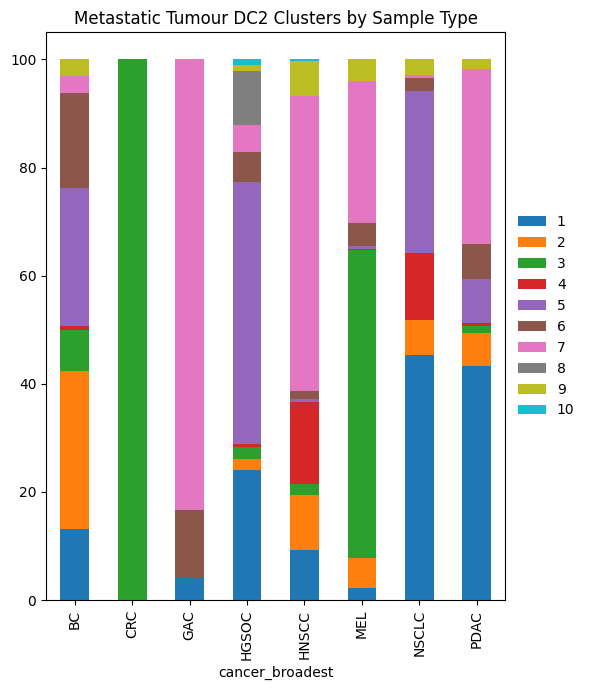

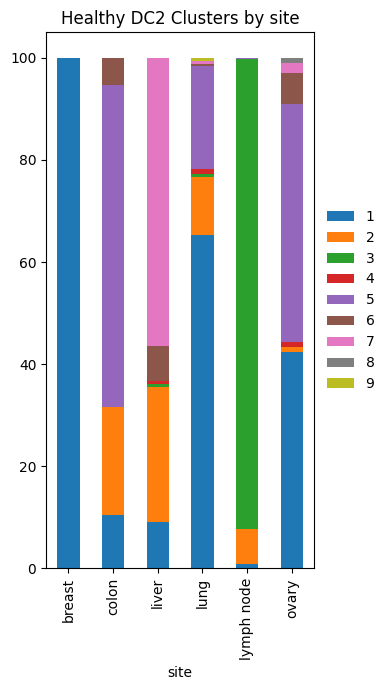

In [26]:
ct = pd.crosstab(data_DC2_primary.obs["cancer_broadest"], data_DC2_primary.obs["cDC2_Atlas_Subclusters"])
ct_pct = ct.apply(lambda r: r / r.sum() * 100, axis=1)
colours = [colour_dict[col] for col in ct_pct.columns]
ct_pct.plot.bar(stacked=True, figsize=(6,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Primary Tumour DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_primary_10_clusters_sample_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

ct = pd.crosstab(data_DC2_mets.obs["cancer_broadest"], data_DC2_mets.obs["cDC2_Atlas_Subclusters"])
ct_pct = ct.apply(lambda r: r / r.sum() * 100, axis=1)
colours = [colour_dict[col] for col in ct_pct.columns]
ct_pct.plot.bar(stacked=True, figsize=(6,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Metastatic Tumour DC2 Clusters by Sample Type")
plt.tight_layout()  
plt.savefig("barplot_DC2_mets_10_clusters_sample_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

ct = pd.crosstab(data_DC2_H.obs["site"], data_DC2_H.obs["cDC2_Atlas_Subclusters"])
ct_pct = ct.apply(lambda r: r / r.sum() * 100, axis=1)
colours = [colour_dict[col] for col in ct_pct.columns]
ct_pct.plot.bar(stacked=True, figsize=(4,7), color=colours)
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False)
plt.title("Healthy DC2 Clusters by site")
plt.tight_layout()  
plt.savefig("barplot_DC2_Healthy_10_clusters_sample_type.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [90]:
# make table of metastatic samples showing cancer_broadest vs site:
pd.crosstab(
    data_DC2_mets.obs["cancer_broadest"],
    data_DC2_mets.obs["site"]
)

site,bowel,brain,liver,lung,lymph node,omentum,ovary,peritoneum,upper abdomen
cancer_broadest,,,,,,,,,
BC,0,0,0,0,130,0,0,0,0
CRC,0,0,0,0,0,0,0,35,0
GAC,0,0,0,0,0,0,24,0,0
HGSOC,303,0,51,0,0,882,0,215,275
HNSCC,0,0,48,174,57,0,0,0,0
MEL,0,169,0,0,265,0,0,0,0
NSCLC,0,84,0,0,86,0,0,0,0
PDAC,0,0,207,10,0,0,0,0,0


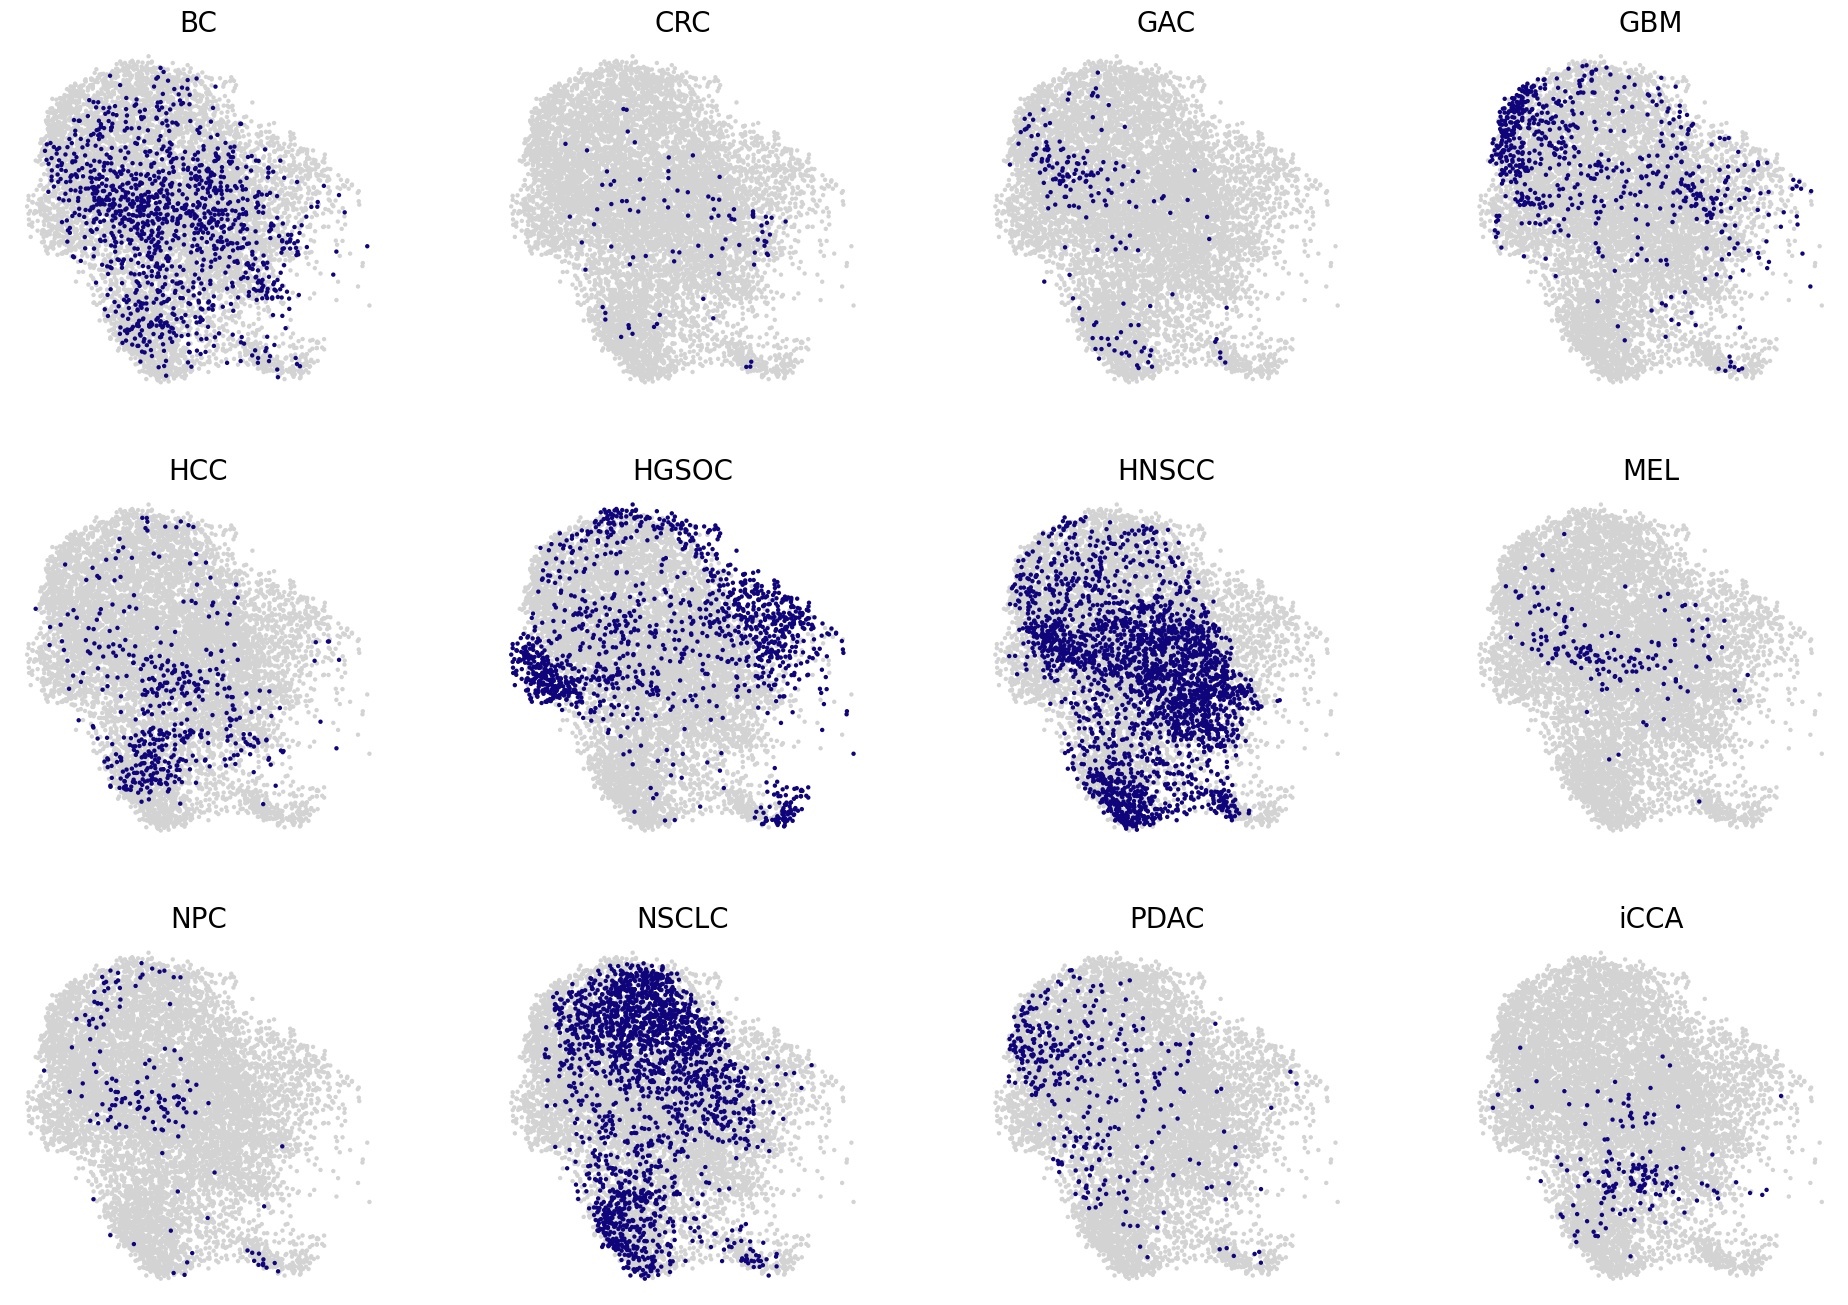

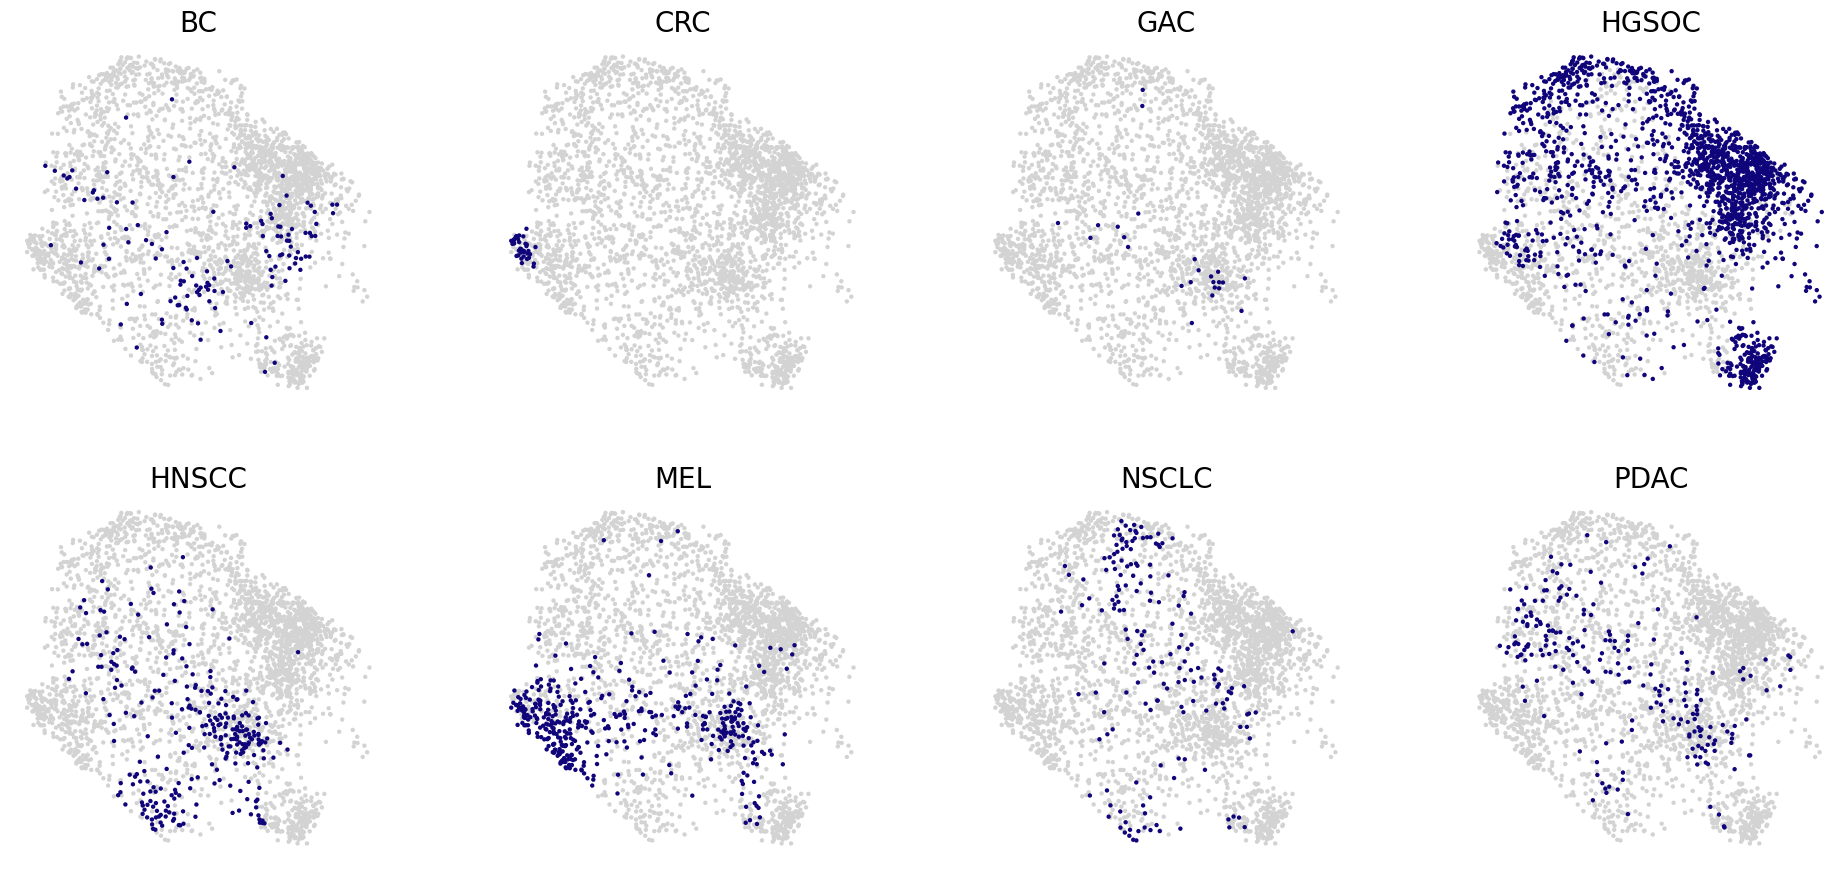

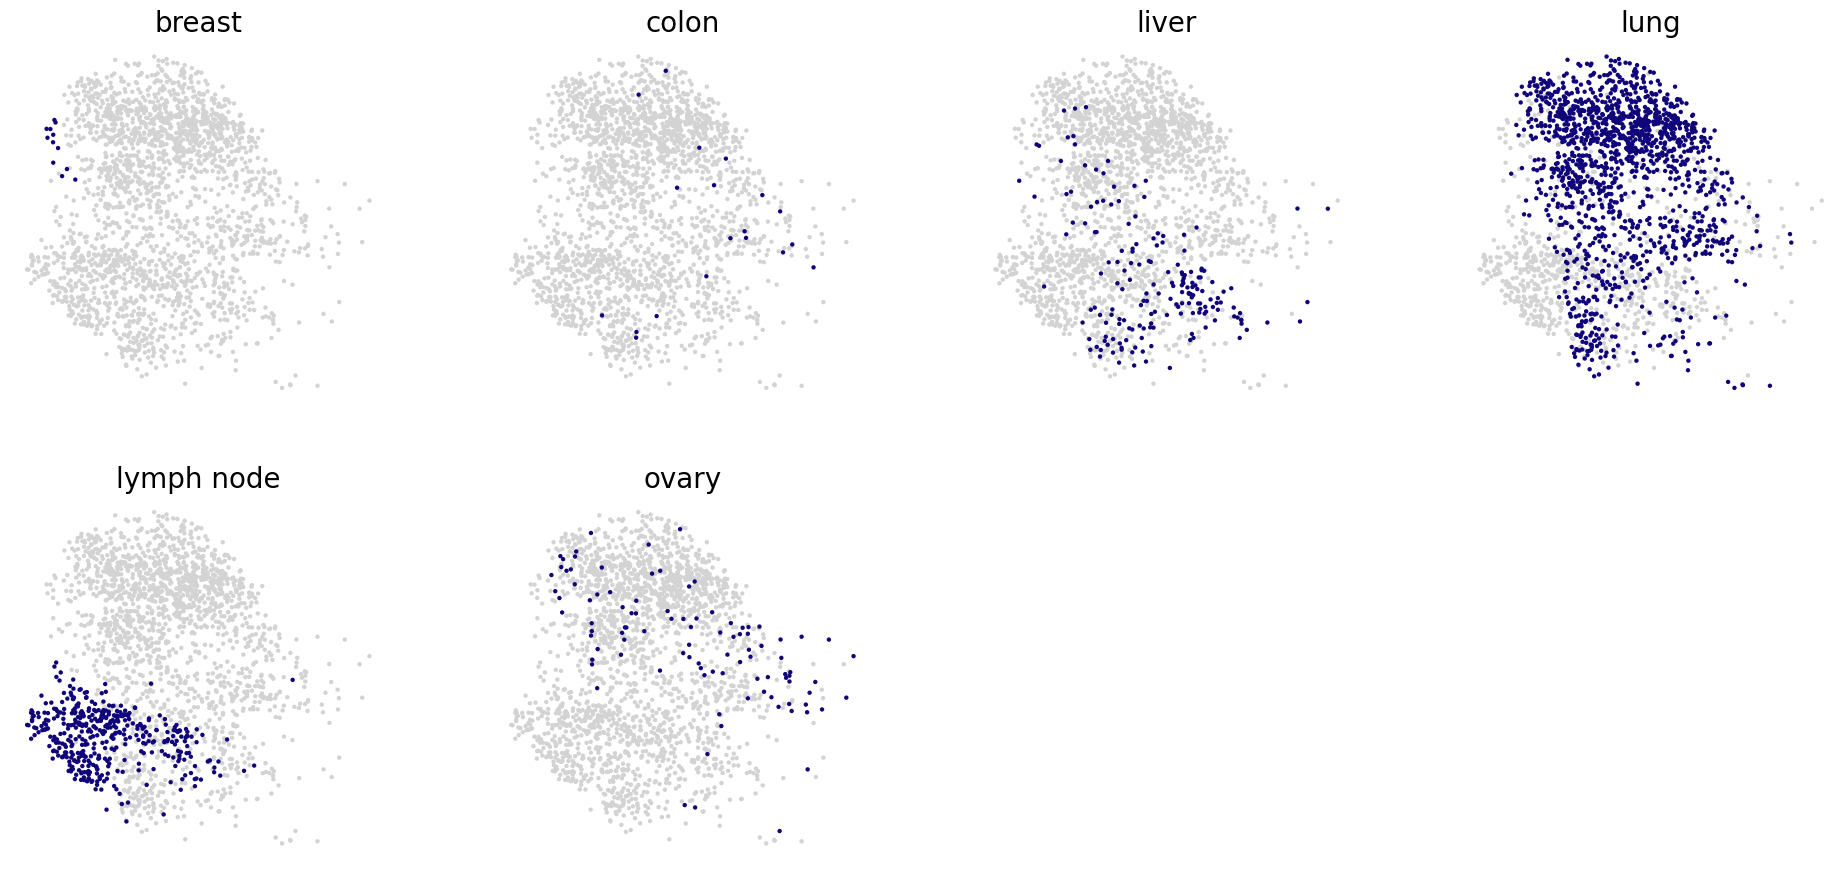

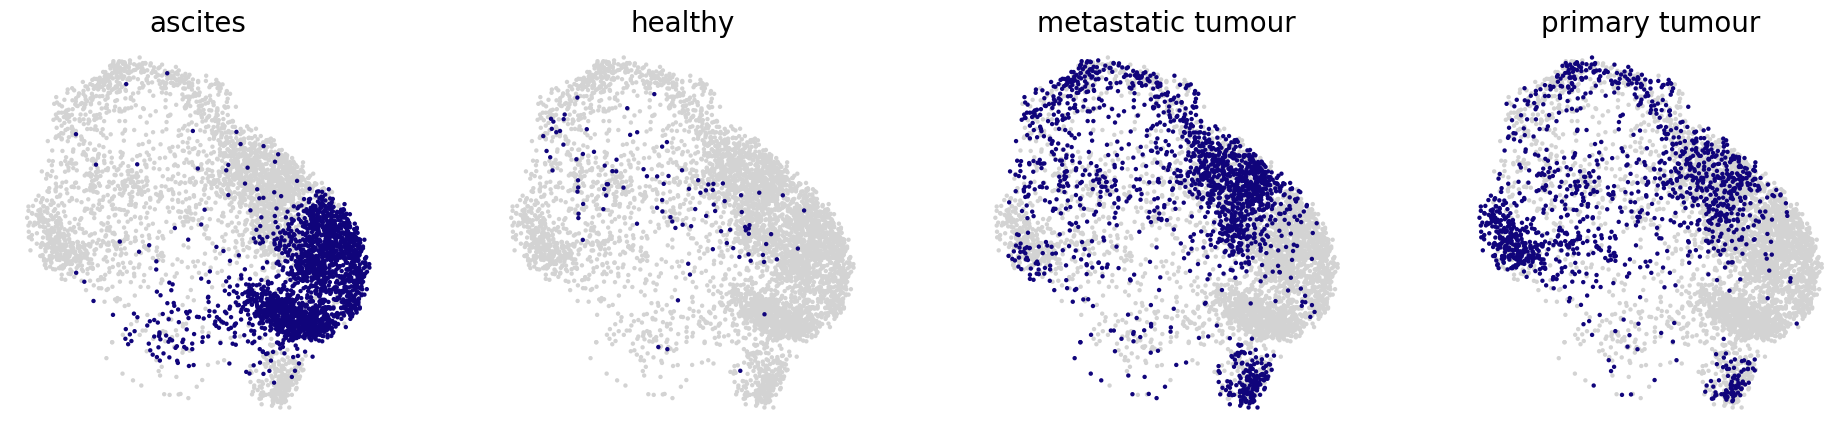

In [94]:
with plt.rc_context({"figure.figsize": (5, 5)}):
    fig1 = cluster_small_multiples(data_DC2_primary, "cancer_broadest", title_fontsize=20)
    plt.show()
    fig2 = cluster_small_multiples(data_DC2_mets, "cancer_broadest", title_fontsize=20)
    plt.show()
    fig3 = cluster_small_multiples(data_DC2_H, "site", title_fontsize=20)
    plt.show()
    fig4 = cluster_small_multiples(data_DC2_OC, "sample_type_major2", title_fontsize=20)
    plt.show()

## calculate DEGs from alternative annotation (with CD207 pops combined)

In [8]:
# Assign DC2 annotations:
data_DC2.obs["cDC2_sub_annotated_grouped"] = data_DC2.obs["cDC2_Atlas_Subclusters"].map(
    {
        "1": "DC3-like cDC2",
        "3": "IL-1B cDC2",
        "4": "CD207 cDC2 c4,c8,c9",
        "5": "classical cDC2",
        "6": "ascites classical cDC2",
        "7": "classical cDC2",
        "8": "CD207 cDC2 c4,c8,c9",
        "9": "CD207 cDC2 c4,c8,c9",
    }
)

/scratch/temp/28455729/ipykernel_1152939/189787154.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


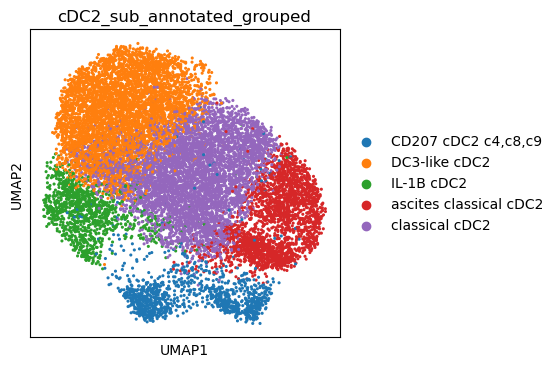

In [9]:
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC2, color="cDC2_sub_annotated_grouped", size=20)

In [10]:
#Calculate DEGs between new cDC2 annotations 
sc.tl.rank_genes_groups(data_DC2, groupby="cDC2_sub_annotated_grouped", method="wilcoxon", key_added="cDC2_sub_annotated_groups_DEGS")

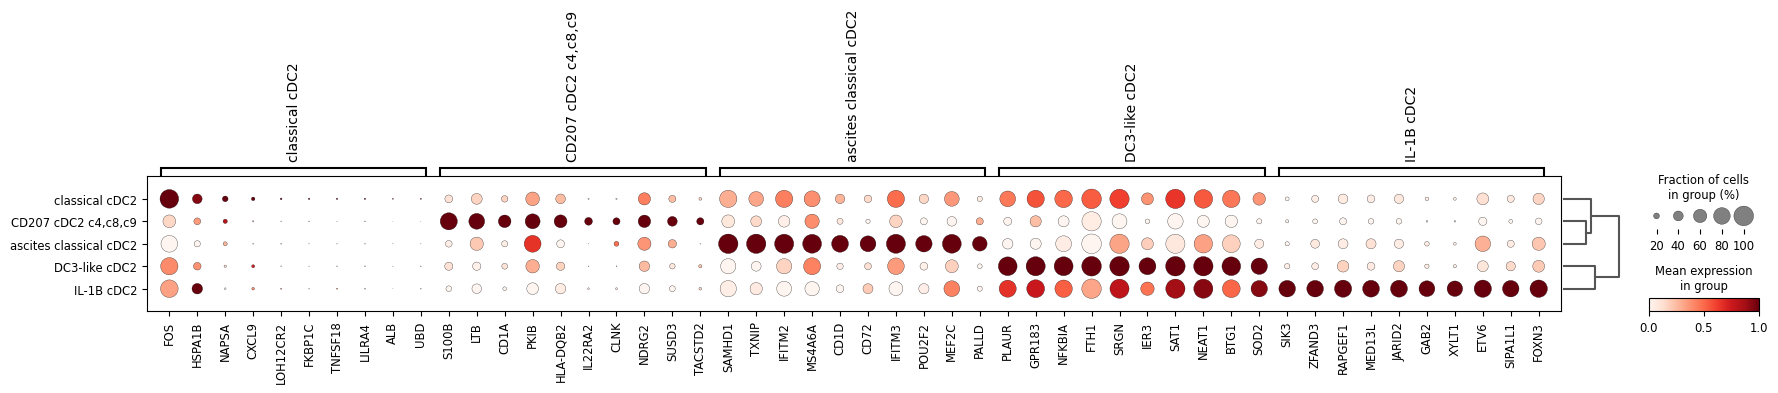

In [12]:
#visualise the top 10 DEG genes for each cluster
sc.pl.rank_genes_groups_dotplot(
    data_DC2, groupby="cDC2_sub_annotated_grouped", standard_scale="var", n_genes=10, min_logfoldchange=1, key="cDC2_sub_annotated_groups_DEGS"
)